In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)


In [63]:
# ==============================================================================================
# STEP 1: Load and select final 2024-confirmed column list relevant for Diabetes Prediction
# ==============================================================================================

final_vars = [
    # Target
    'DIABETE4',
    
    # Weight/BMI
    '_BMI5', '_RFBMI5',
    
    # Cardiometabolic (BP/cholesterol dropped -- not in 2024 core)
    'CVDSTRK3',      # stroke history
    '_MICHD',        # heart disease/MI
    'CHCKDNY2',      # kidney disease
    
    # Lifestyle (fruit/veg dropped -- not in 2024 core)
    'SMOKE100',      # smoking (raw)
    '_RFDRHV9',      # heavy drinking 
    '_TOTINDA',      # physical activity
    
    # General health
    'GENHLTH',       # raw 5-level self-rated health
    'PHYSHLTH',      # raw days physical health not good
    'MENTHLTH',      # raw days mental health not good
    'DIFFWALK',      # difficulty walking
    
    # Healthcare access
    '_HLTHPL2',      # has insurance -- RENAMED from _HLTHPLN
    'MEDCOST1',      # skipped care due to cost
    'CHECKUP1',      # time since last checkup
    
    # Demographics
    '_SEX',
    '_AGEG5YR',
    'EDUCA',
    'INCOME3',
    '_RACEGR3',
]

In [64]:
df = pd.read_sas(r"C:\Users\vithy\OneDrive\Documents\UCBerkley_Applied_AI_ML_2026\Capstone Project\data\LLCP2024XPT\LLCP2024.XPT", format='xport', encoding='latin1')

available = [v for v in final_vars if v in df.columns]
missing = [v for v in final_vars if v not in df.columns]
print(f"Found: {len(available)}/{len(final_vars)}")
if missing:
    print(f"Still missing: {missing}")

df_brfss2024 = df[available].copy()


Found: 21/21


In [65]:

# ================================================================
# STEP 2: Recode missing-value codes to NaN
# ================================================================

missing_code_map = {
    'DIABETE4':  [7, 9],
    '_BMI5':     [],
    '_RFBMI5':   [9],
    'CVDSTRK3':  [7, 9],
    '_MICHD':    [],
    'CHCKDNY2':  [7, 9],
    'SMOKE100':  [7, 9],
    '_RFDRHV9':  [9],
    '_TOTINDA':  [9],
    'GENHLTH':   [7, 9],
    'PHYSHLTH':  [77, 99],   # 88 = zero days, handled separately below
    'MENTHLTH':  [77, 99],   # 88 = zero days, handled separately below
    'DIFFWALK':  [7, 9],
    '_HLTHPL2':  [9],
    'MEDCOST1':  [7, 9],
    'CHECKUP1':  [7, 9],
    '_SEX':      [],
    '_AGEG5YR':  [14],
    'EDUCA':     [9],
    'INCOME3':   [77, 99],
    '_RACEGR3':  [9],
}

for col, codes in missing_code_map.items():
    if col in df_brfss2024.columns and codes:
        df_brfss2024[col] = df_brfss2024[col].replace(codes, np.nan)

for col in ['PHYSHLTH', 'MENTHLTH']:
    if col in df_brfss2024.columns:
       df_brfss2024[col] = df_brfss2024[col].replace(88, 0)

df_brfss2024['_BMI5'] = df_brfss2024['_BMI5'] / 100  # BRFSS stores BMI with 2 implied decimals

print("\nMissing values per column after recoding:")
print(df_brfss2024.isnull().sum())


Missing values per column after recoding:
DIABETE4     1034
_BMI5       43037
_RFBMI5     43037
CVDSTRK3     1452
_MICHD       5206
CHCKDNY2     1979
SMOKE100    31472
_RFDRHV9    46698
_TOTINDA     1315
GENHLTH      1310
PHYSHLTH    11067
MENTHLTH     8156
DIFFWALK    20452
_HLTHPL2    18544
MEDCOST1     1673
CHECKUP1     5334
_SEX            0
_AGEG5YR     8310
EDUCA        2363
INCOME3     87423
_RACEGR3     9103
dtype: int64


In [66]:
# =============================================================================================================
# STEP 3: Binary target
# A classifier needs a clean binary target (0 or 1), so this line collapses those 4 categories down to two.
# For the analysis, we're combining diabetic & pre-diabetic into diabetic
# ==============================================================================================================

df_brfss2024['DIABETE_BINARY'] = df_brfss2024['DIABETE4'].map({
    1: 1,   # Yes, diabetic
    2: 0,   # Yes, only during pregnancy -> treat as non-diabetic
    3: 0,   # No
    4: 1,   # Prediabetes/borderline -> grouped with diabetic
})

# Dropping if target value is missing
df_brfss2024 = df_brfss2024.dropna(subset=['DIABETE_BINARY'])

print("\nTarget distribution:")
print(df_brfss2024['DIABETE_BINARY'].value_counts())
print(f"\nFinal shape: {data.shape}")


Target distribution:
DIABETE_BINARY
0.0    379520
1.0     77116
Name: count, dtype: int64

Final shape: (456636, 22)


In [67]:
# ================================================================
# Basic shape and dtypes
# ================================================================
print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"Shape: {df_brfss2024.shape[0]:,} rows x {df_brfss2024.shape[1]} columns\n")
print(df_brfss2024.dtypes)

DATASET OVERVIEW
Shape: 456,636 rows x 22 columns

DIABETE4          float64
_BMI5             float64
_RFBMI5           float64
CVDSTRK3          float64
_MICHD            float64
CHCKDNY2          float64
SMOKE100          float64
_RFDRHV9          float64
_TOTINDA          float64
GENHLTH           float64
PHYSHLTH          float64
MENTHLTH          float64
DIFFWALK          float64
_HLTHPL2          float64
MEDCOST1          float64
CHECKUP1          float64
_SEX              float64
_AGEG5YR          float64
EDUCA             float64
INCOME3           float64
_RACEGR3          float64
DIABETE_BINARY    float64
dtype: object


In [68]:
# ================================================================
# STEP 4: Missing value analysis (raw — before BRFSS recoding)
# ================================================================
print("\n" + "="*70)
print("MISSING VALUE ANALYSIS (raw, before BRFSS missing-code recoding)")
print("="*70)

missing_summary = pd.DataFrame({
    'missing_count': df_brfss2024.isnull().sum(),
    'missing_pct': (df_brfss2024.isnull().sum() / len(df_brfss2024) * 100).round(2)
}).sort_values('missing_pct', ascending=False)
print(missing_summary)


MISSING VALUE ANALYSIS (raw, before BRFSS missing-code recoding)
                missing_count  missing_pct
INCOME3                 86930        19.04
_RFDRHV9                46440        10.17
_RFBMI5                 42723         9.36
_BMI5                   42723         9.36
SMOKE100                31267         6.85
DIFFWALK                20273         4.44
_HLTHPL2                18358         4.02
PHYSHLTH                10935         2.39
_RACEGR3                 8939         1.96
_AGEG5YR                 8143         1.78
MENTHLTH                 8021         1.76
CHECKUP1                 5233         1.15
_MICHD                   4943         1.08
EDUCA                    2249         0.49
CHCKDNY2                 1756         0.38
MEDCOST1                 1596         0.35
_TOTINDA                 1243         0.27
CVDSTRK3                 1255         0.27
GENHLTH                  1252         0.27
DIABETE4                    0         0.00
_SEX                        0  

In [69]:
# ================================================================
# STEP 5: Missingness per row (are missing values scattered or
# concentrated in a subset of respondents?)
# ================================================================
print("\n" + "="*70)
print("MISSINGNESS PER ROW")
print("="*70)

row_missing = df_brfss2024.isnull().sum(axis=1)
print(row_missing.value_counts().sort_index())
print(f"\nRows with 0 missing values: {(row_missing == 0).sum():,} "
      f"({(row_missing == 0).mean()*100:.1f}%)")
print(f"Rows with 3+ missing values: {(row_missing >= 3).sum():,} "
      f"({(row_missing >= 3).mean()*100:.1f}%)")


MISSINGNESS PER ROW
0     300031
1      77564
2      34838
3      17935
4       7117
5       5361
6      10315
7       2362
8        708
9        269
10        88
11        28
12        10
13         4
14         2
15         2
16         1
18         1
Name: count, dtype: int64

Rows with 0 missing values: 300,031 (65.7%)
Rows with 3+ missing values: 44,203 (9.7%)


In [70]:
# ================================================================
# STEP 5b: Drop rows with any missing values (initial modeling pass)
# ================================================================
print("\n" + "="*70)
print("DROPPING ROWS WITH MISSING VALUES")
print("="*70)

rows_before = len(df_brfss2024)
df_brfss2024_clean = df_brfss2024.dropna()
rows_after = len(df_brfss2024_clean)

print(f"Rows before dropna: {rows_before:,}")
print(f"Rows after dropna:  {rows_after:,}")
print(f"Rows dropped:       {rows_before - rows_after:,} "
      f"({(rows_before - rows_after) / rows_before * 100:.1f}%)")

# Sanity check: target class balance shouldn't shift dramatically
print("\nTarget balance after dropna:")
print(df_brfss2024_clean['DIABETE_BINARY'].value_counts(normalize=True).round(4) * 100)


DROPPING ROWS WITH MISSING VALUES
Rows before dropna: 456,636
Rows after dropna:  300,031
Rows dropped:       156,605 (34.3%)

Target balance after dropna:
DIABETE_BINARY
0.0    83.36
1.0    16.64
Name: proportion, dtype: float64


In [71]:
# ================================================================
# STEP 6: Continuous variable summary
# ================================================================
print("\n" + "="*70)
print("CONTINUOUS VARIABLE SUMMARY")
print("="*70)

continuous_vars = ['_BMI5', 'PHYSHLTH', 'MENTHLTH']
cont_present = [c for c in continuous_vars if c in df_brfss2024_clean.columns]
print(df_brfss2024_clean[cont_present].describe().T)



CONTINUOUS VARIABLE SUMMARY
             count       mean       std   min    25%    50%    75%    max
_BMI5     300031.0  28.769557  6.569090  12.0  24.33  27.59  31.98  99.84
PHYSHLTH  300031.0   4.452317  8.728504   0.0   0.00   0.00   4.00  30.00
MENTHLTH  300031.0   4.419540  8.243682   0.0   0.00   0.00   5.00  30.00


In [72]:

# ================================================================
# STEP 7: Categorical variable frequency tables
# ================================================================
print("\n" + "="*70)
print("CATEGORICAL VARIABLE FREQUENCIES")
print("="*70)

categorical_vars = [c for c in df_brfss2024_clean.columns if c not in continuous_vars]
for col in categorical_vars:
    print(f"\n--- {col} ---")
    counts = df_brfss2024_clean[col].value_counts(dropna=False).sort_index()
    pcts = (df_brfss2024_clean[col].value_counts(dropna=False, normalize=True) * 100).round(2).sort_index()
    summary = pd.DataFrame({'count': counts, 'pct': pcts})
    print(summary)



CATEGORICAL VARIABLE FREQUENCIES

--- DIABETE4 ---
           count    pct
DIABETE4               
1.0        42721  14.24
2.0         2157   0.72
3.0       247961  82.65
4.0         7192   2.40

--- _RFBMI5 ---
          count    pct
_RFBMI5               
1.0       88380  29.46
2.0      211651  70.54

--- CVDSTRK3 ---
           count    pct
CVDSTRK3               
1.0        12821   4.27
2.0       287210  95.73

--- _MICHD ---
         count    pct
_MICHD               
1.0      27781   9.26
2.0     272250  90.74

--- CHCKDNY2 ---
           count    pct
CHCKDNY2               
1.0        15327   5.11
2.0       284704  94.89

--- SMOKE100 ---
           count    pct
SMOKE100               
1.0       119687  39.89
2.0       180344  60.11

--- _RFDRHV9 ---
           count    pct
_RFDRHV9               
1.0       280669  93.55
2.0        19362   6.45

--- _TOTINDA ---
           count    pct
_TOTINDA               
1.0       236241  78.74
2.0        63790  21.26

--- GENHLTH ---
    

In [73]:
# ================================================================
# STEP 8: Target variable class balance
# ================================================================
print("\n" + "="*70)
print("TARGET VARIABLE: DIABETE_BINARY")
print("="*70)

target_counts = df_brfss2024_clean['DIABETE_BINARY'].value_counts(dropna=False)
target_pcts = df_brfss2024_clean['DIABETE_BINARY'].value_counts(dropna=False, normalize=True) * 100
print(pd.DataFrame({'count': target_counts, 'pct': target_pcts.round(2)}))

vc = df_brfss2024_clean['DIABETE_BINARY'].value_counts()
print(f"\nImbalance ratio (majority:minority): {vc.max()/vc.min():.2f} : 1")


TARGET VARIABLE: DIABETE_BINARY
                 count    pct
DIABETE_BINARY               
0.0             250118  83.36
1.0              49913  16.64

Imbalance ratio (majority:minority): 5.01 : 1


In [74]:
df = df_brfss2024_clean

In [75]:
df.head()

,DIABETE4,_BMI5,_RFBMI5,CVDSTRK3,_MICHD,CHCKDNY2,SMOKE100,_RFDRHV9,_TOTINDA,GENHLTH,PHYSHLTH,MENTHLTH,DIFFWALK,_HLTHPL2,MEDCOST1,CHECKUP1,_SEX,_AGEG5YR,EDUCA,INCOME3,_RACEGR3,DIABETE_BINARY
1,3.0,25.83,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,1.0,2.0,1.0,1.0,13.0,6.0,11.0,1.0,0.0
3,3.0,25.09,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,2.0,1.0,2.0,1.0,1.0,13.0,6.0,6.0,1.0,0.0
4,3.0,19.77,1.0,2.0,2.0,2.0,2.0,1.0,2.0,3.0,0.0,0.0,1.0,1.0,2.0,1.0,1.0,6.0,5.0,3.0,1.0,0.0
5,1.0,33.36,2.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,7.0,0.0,2.0,1.0,2.0,1.0,1.0,7.0,4.0,9.0,1.0,1.0
6,3.0,31.47,2.0,2.0,1.0,2.0,2.0,1.0,1.0,4.0,0.0,0.0,2.0,1.0,2.0,1.0,2.0,11.0,5.0,6.0,1.0,0.0


C:\Users\vithy\AppData\Local\Temp\ipykernel_32648\677401658.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['diabetes_lbl'] = df['DIABETE_BINARY'].map(label_map_target)


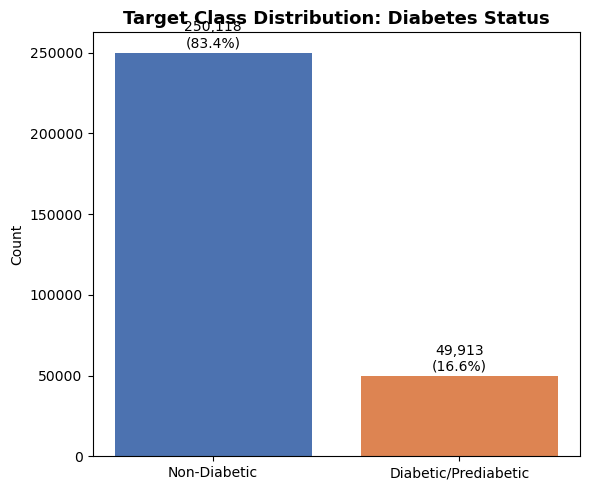

In [77]:
# ================================================================
# FIGURE 1: Target class distribution
# ================================================================
label_map_target = {0: 'Non-Diabetic', 1: 'Diabetic/Prediabetic'}
df['diabetes_lbl'] = df['DIABETE_BINARY'].map(label_map_target)

fig, ax = plt.subplots(figsize=(6, 5))
counts = df['diabetes_lbl'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 3000,
             f'{val:,}\n({val / len(df) * 100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Class Distribution: Diabetes Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()

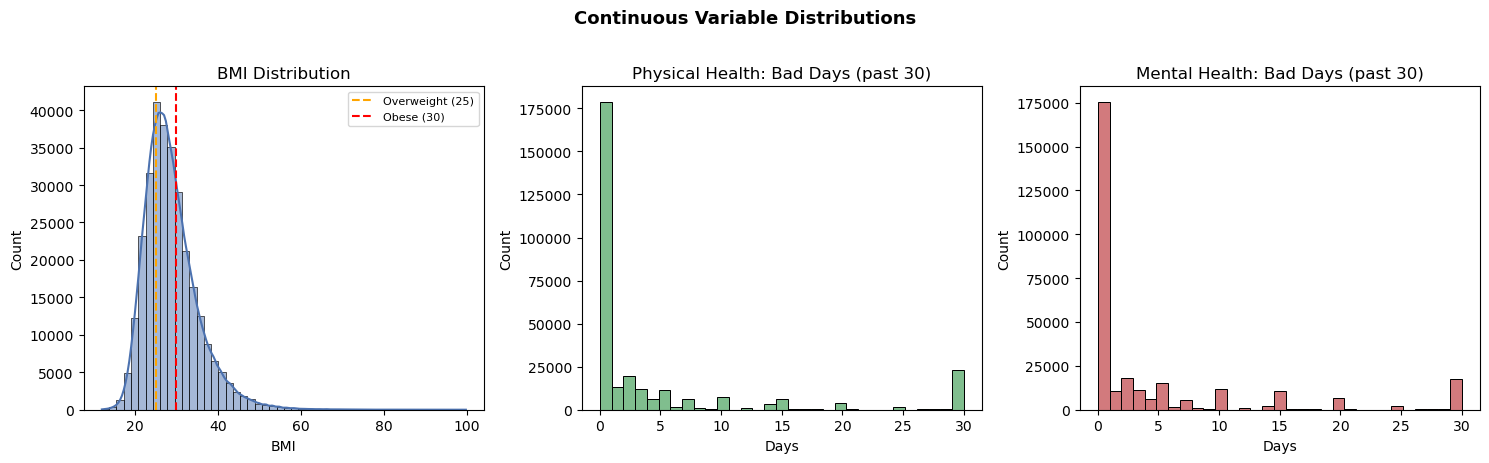

In [78]:
# ================================================================
# FIGURE 2: Continuous variable distributions
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(df['_BMI5'], bins=50, ax=axes[0], color='#4C72B0', kde=True)
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')
axes[0].axvline(25, color='orange', linestyle='--', label='Overweight (25)')
axes[0].axvline(30, color='red', linestyle='--', label='Obese (30)')
axes[0].legend(fontsize=8)

sns.histplot(df['PHYSHLTH'], bins=31, ax=axes[1], color='#55A868')
axes[1].set_title('Physical Health: Bad Days (past 30)')
axes[1].set_xlabel('Days')

sns.histplot(df['MENTHLTH'], bins=31, ax=axes[2], color='#C44E52')
axes[2].set_title('Mental Health: Bad Days (past 30)')
axes[2].set_xlabel('Days')

plt.suptitle('Continuous Variable Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

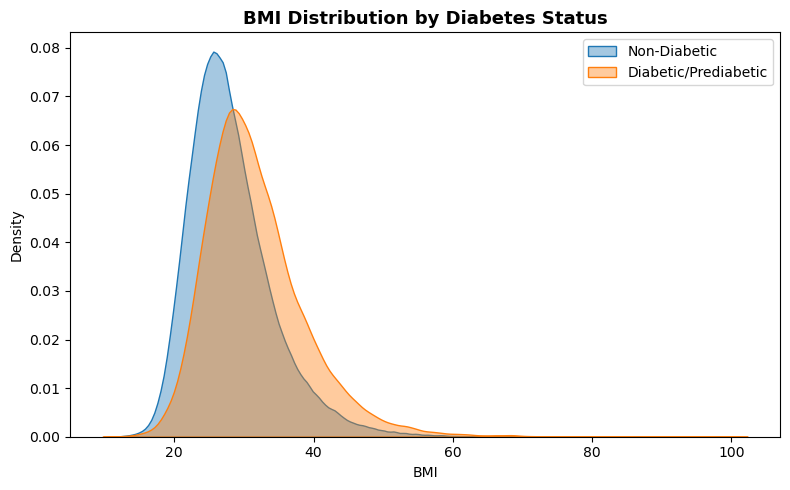

In [79]:
# ================================================================
# FIGURE 3: BMI distribution split by diabetes status (overlay)
# ================================================================
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df[df['DIABETE_BINARY'] == 0], x='_BMI5', label='Non-Diabetic',
            fill=True, alpha=0.4, ax=ax)
sns.kdeplot(data=df[df['DIABETE_BINARY'] == 1], x='_BMI5', label='Diabetic/Prediabetic',
            fill=True, alpha=0.4, ax=ax)
ax.set_title('BMI Distribution by Diabetes Status', fontsize=13, fontweight='bold')
ax.set_xlabel('BMI')
#ax.set_xlim(10, 60)
ax.legend()
plt.tight_layout()

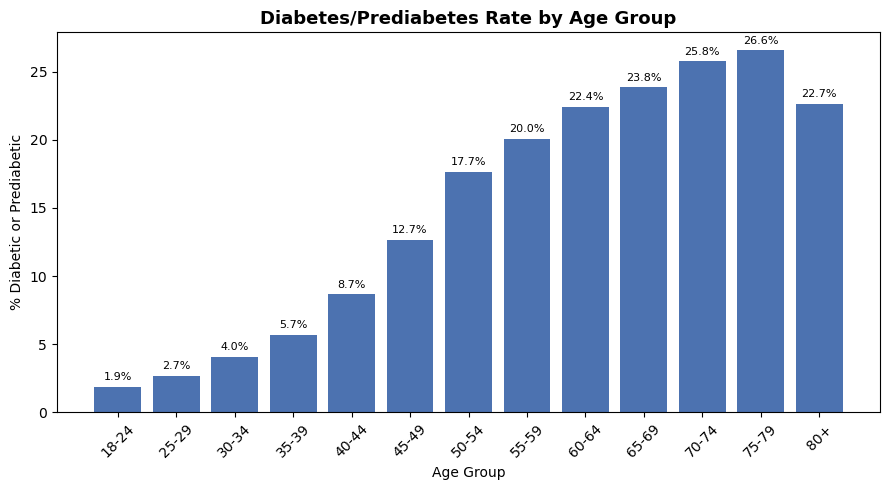

In [80]:

# ================================================================
# FIGURE 4: Diabetes rate by age group
# ================================================================
age_labels = {1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44', 6: '45-49',
              7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79', 13: '80+'}
rate_by_age = df.groupby('_AGEG5YR')['DIABETE_BINARY'].mean().sort_index() * 100
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([age_labels[i] for i in rate_by_age.index], rate_by_age.values, color='#4C72B0')
ax.set_title('Diabetes/Prediabetes Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('% Diabetic or Prediabetic')
ax.set_xlabel('Age Group')
plt.xticks(rotation=45)
for bar, val in zip(bars, rate_by_age.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=8)
plt.tight_layout()

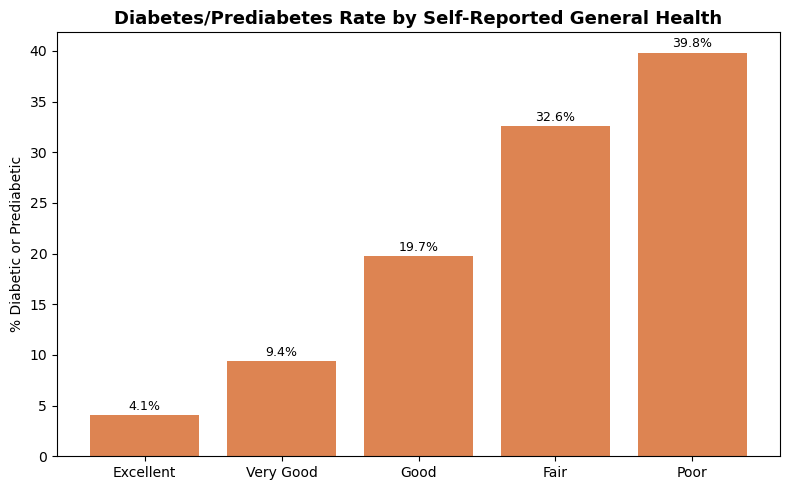

In [81]:
# ================================================================
# FIGURE 5: Diabetes rate by general health status
# ================================================================
genhlth_labels = {1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'}
rate_by_health = df.groupby('GENHLTH')['DIABETE_BINARY'].mean().sort_index() * 100
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([genhlth_labels[i] for i in rate_by_health.index], rate_by_health.values, color='#DD8452')
ax.set_title('Diabetes/Prediabetes Rate by Self-Reported General Health', fontsize=13, fontweight='bold')
ax.set_ylabel('% Diabetic or Prediabetic')
for bar, val in zip(bars, rate_by_health.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()

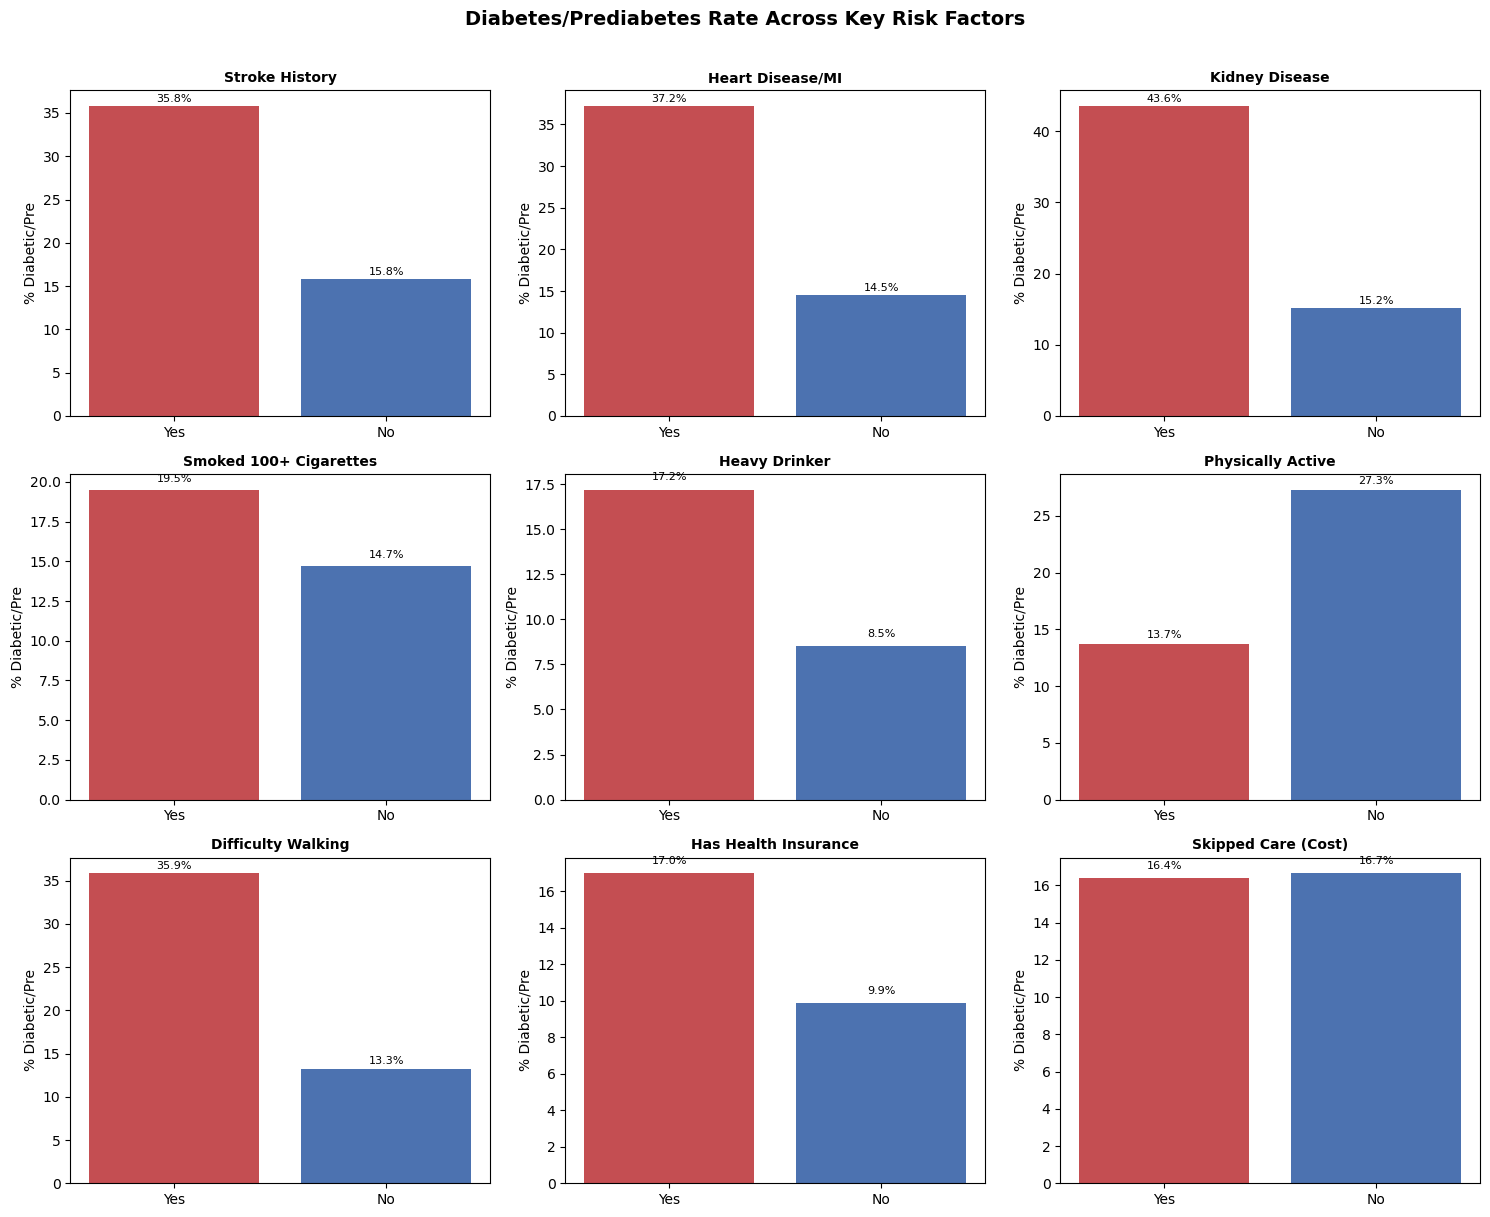

In [82]:
# ================================================================
# FIGURE 6: Diabetes rate across key binary risk factors (3x3 grid)
# NOTE: these columns are still in RAW BRFSS coding (1=Yes, 2=No)
# ================================================================
binary_factors = {
    'CVDSTRK3': 'Stroke History',
    '_MICHD': 'Heart Disease/MI',
    'CHCKDNY2': 'Kidney Disease',
    'SMOKE100': 'Smoked 100+ Cigarettes',
    '_RFDRHV9': 'Heavy Drinker',
    '_TOTINDA': 'Physically Active',
    'DIFFWALK': 'Difficulty Walking',
    '_HLTHPL2': 'Has Health Insurance',
    'MEDCOST1': 'Skipped Care (Cost)',
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, (col, label) in enumerate(binary_factors.items()):
    rates = df.groupby(col)['DIABETE_BINARY'].mean() * 100
    order_idx = sorted(rates.index)
    cat_labels = ['Yes', 'No'] if order_idx == [1, 2] else [str(int(x)) for x in order_idx]
    bars = axes[i].bar(cat_labels, [rates[x] for x in order_idx], color=['#C44E52', '#4C72B0'])
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('% Diabetic/Pre')
    for bar, val in zip(bars, [rates[x] for x in order_idx]):
        axes[i].text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=8)

plt.suptitle('Diabetes/Prediabetes Rate Across Key Risk Factors', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

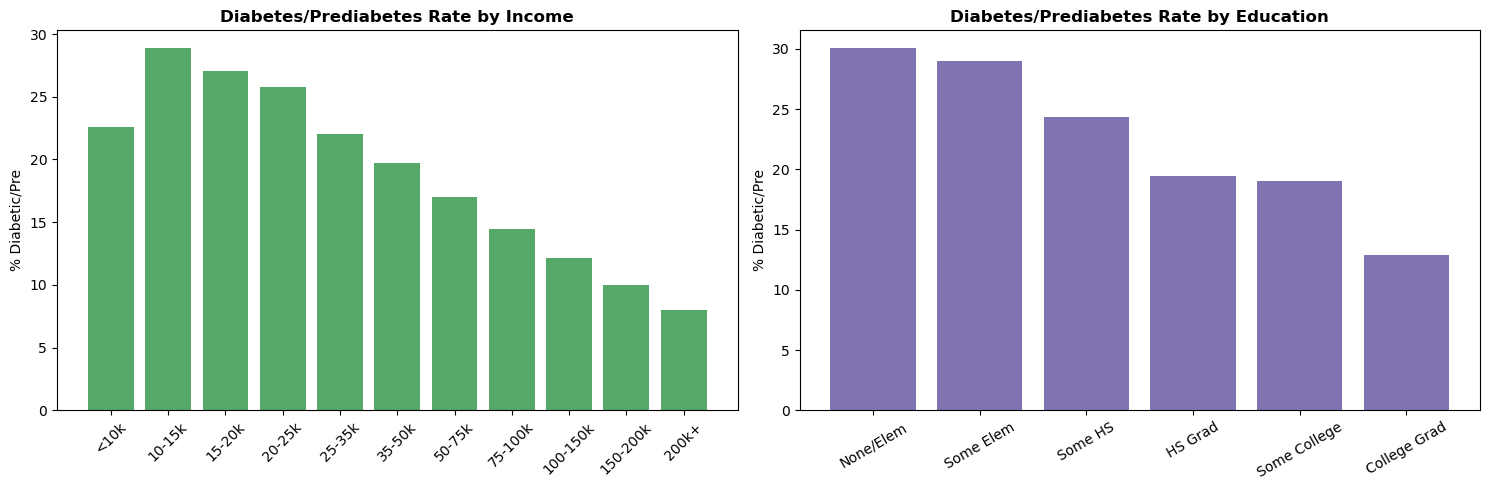

In [83]:
# ================================================================
# FIGURE 7: Diabetes rate by income and education
# ================================================================
income_labels = {1: '<10k', 2: '10-15k', 3: '15-20k', 4: '20-25k', 5: '25-35k', 6: '35-50k',
                  7: '50-75k', 8: '75-100k', 9: '100-150k', 10: '150-200k', 11: '200k+'}
educa_labels = {1: 'None/Elem', 2: 'Some Elem', 3: 'Some HS', 4: 'HS Grad',
                 5: 'Some College', 6: 'College Grad'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rate_income = df.groupby('INCOME3')['DIABETE_BINARY'].mean().sort_index() * 100
axes[0].bar([income_labels[i] for i in rate_income.index], rate_income.values, color='#55A868')
axes[0].set_title('Diabetes/Prediabetes Rate by Income', fontweight='bold')
axes[0].set_ylabel('% Diabetic/Pre')
axes[0].tick_params(axis='x', rotation=45)

rate_educ = df.groupby('EDUCA')['DIABETE_BINARY'].mean().sort_index() * 100
axes[1].bar([educa_labels[i] for i in rate_educ.index], rate_educ.values, color='#8172B2')
axes[1].set_title('Diabetes/Prediabetes Rate by Education', fontweight='bold')
axes[1].set_ylabel('% Diabetic/Pre')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()

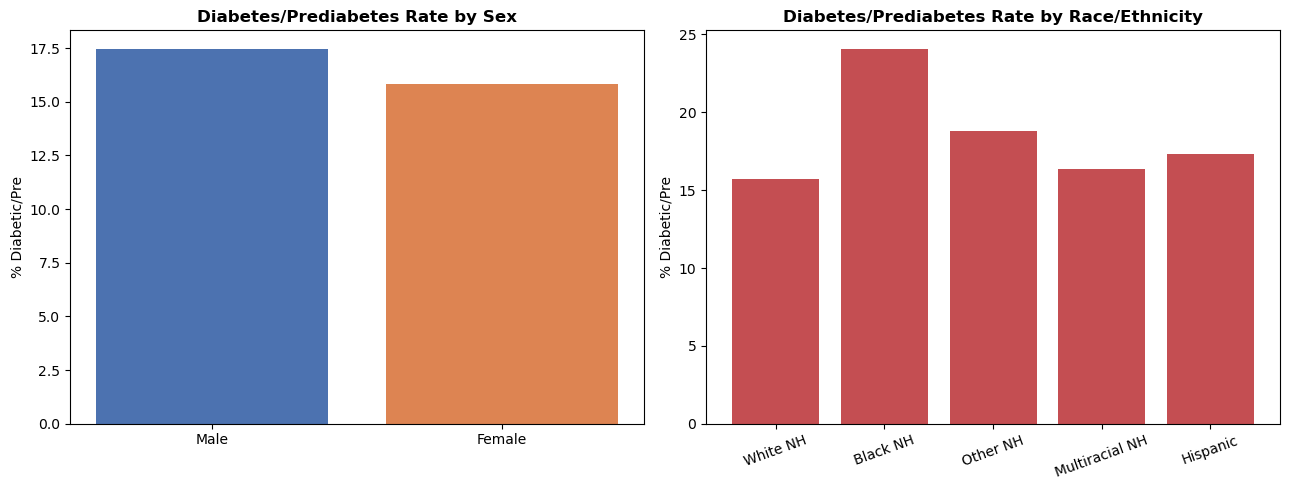

In [85]:
# ================================================================
# FIGURE 8: Diabetes rate by sex and race/ethnicity
# ================================================================
race_labels = {1: 'White NH', 2: 'Black NH', 3: 'Other NH', 4: 'Multiracial NH', 5: 'Hispanic'}
sex_labels = {1: 'Male', 2: 'Female'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rate_sex = df.groupby('_SEX')['DIABETE_BINARY'].mean().sort_index() * 100
axes[0].bar([sex_labels[int(i)] for i in rate_sex.index], rate_sex.values,
            color=['#4C72B0', '#DD8452'])
axes[0].set_title('Diabetes/Prediabetes Rate by Sex', fontweight='bold')
axes[0].set_ylabel('% Diabetic/Pre')

rate_race = df.groupby('_RACEGR3')['DIABETE_BINARY'].mean().sort_index() * 100
axes[1].bar([race_labels[int(i)] for i in rate_race.index], rate_race.values, color='#C44E52')
axes[1].set_title('Diabetes/Prediabetes Rate by Race/Ethnicity', fontweight='bold')
axes[1].set_ylabel('% Diabetic/Pre')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

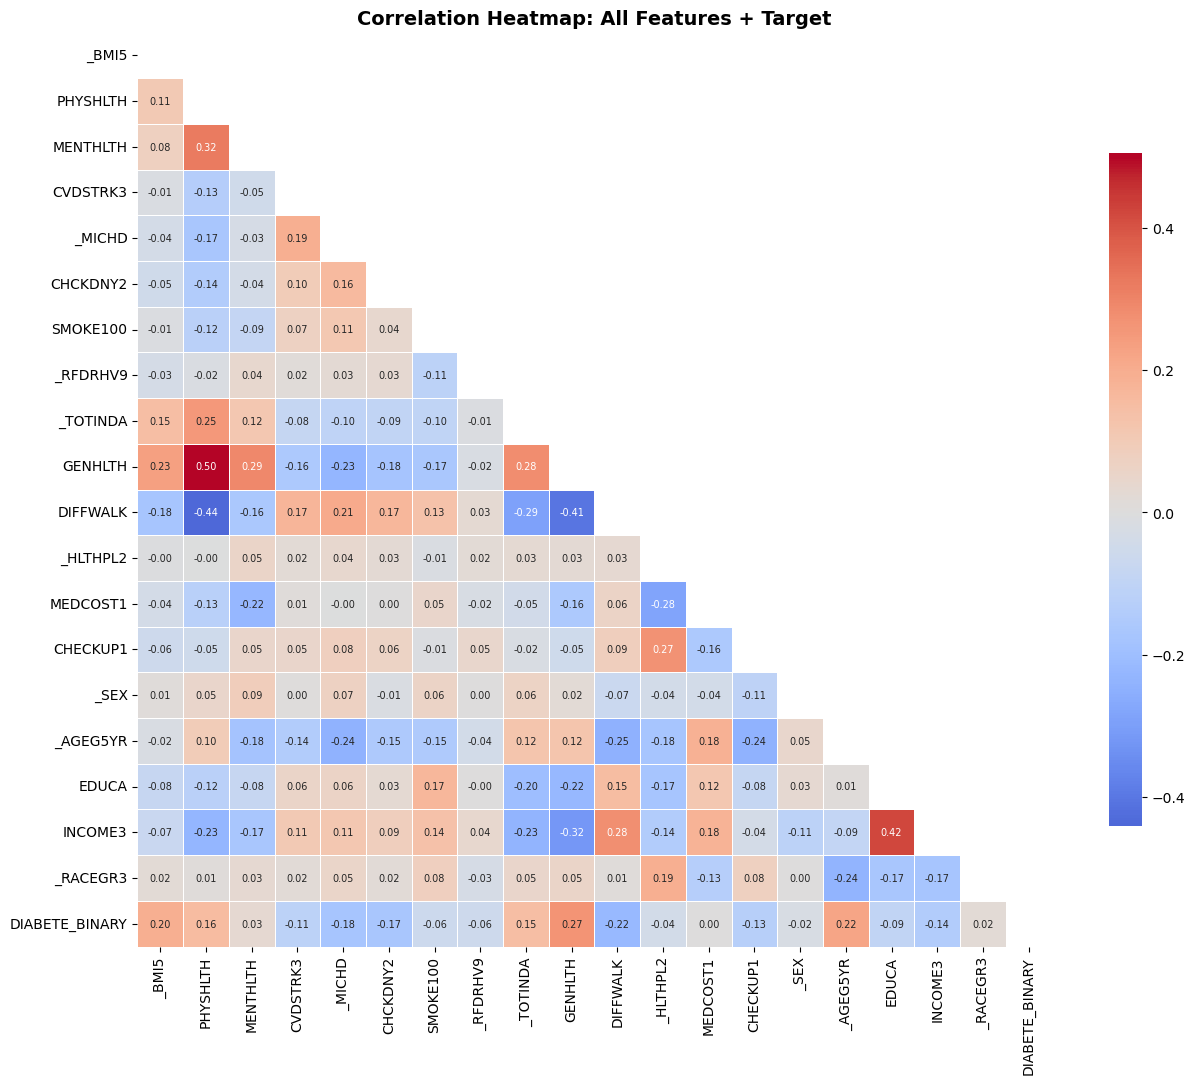

In [86]:
# ================================================================
# FIGURE 9: Correlation heatmap (all numeric features + target)
# NOTE: several binary columns are still in RAW BRFSS coding
# (1=Yes, 2=No), so correlation SIGNS for those columns are
# inverted relative to a standard 1=Yes/0=No encoding. Re-run
# after the modeling-stage recoding step for cleaner sign
# interpretation if needed.
# ================================================================
corr_cols = ['_BMI5', 'PHYSHLTH', 'MENTHLTH', 'CVDSTRK3', '_MICHD', 'CHCKDNY2',
             'SMOKE100', '_RFDRHV9', '_TOTINDA', 'GENHLTH', 'DIFFWALK', '_HLTHPL2',
             'MEDCOST1', 'CHECKUP1', '_SEX', '_AGEG5YR', 'EDUCA', 'INCOME3',
             '_RACEGR3', 'DIABETE_BINARY']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap: All Features + Target', fontsize=14, fontweight='bold')
plt.tight_layout()



Top correlations with target:
GENHLTH     0.267364
_AGEG5YR    0.221010
_BMI5       0.197500
PHYSHLTH    0.155529
_TOTINDA    0.149159
MENTHLTH    0.032054
_RACEGR3    0.021053
MEDCOST1    0.002023
_SEX       -0.021758
_HLTHPL2   -0.041154
_RFDRHV9   -0.057300
SMOKE100   -0.063147
EDUCA      -0.093521
CVDSTRK3   -0.108863
CHECKUP1   -0.128254
INCOME3    -0.143174
CHCKDNY2   -0.167771
_MICHD     -0.176687
DIFFWALK   -0.216394
Name: DIABETE_BINARY, dtype: float64


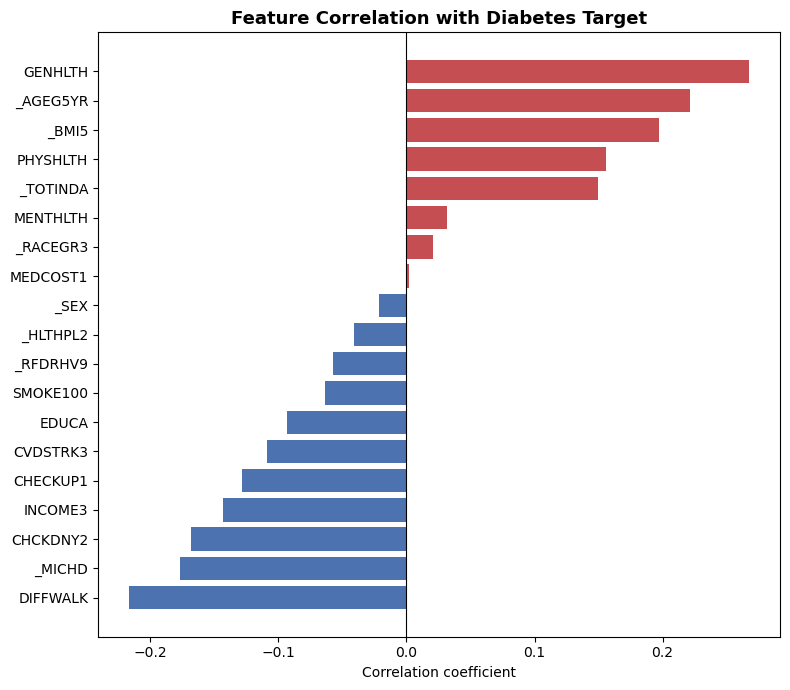

In [88]:
# ================================================================
# FIGURE 10: Top correlations with target, ranked bar chart
# ================================================================
target_corr = corr['DIABETE_BINARY'].drop('DIABETE_BINARY').sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title('Feature Correlation with Diabetes Target', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()

print("\nTop correlations with target:")
print(target_corr.sort_values(ascending=False))

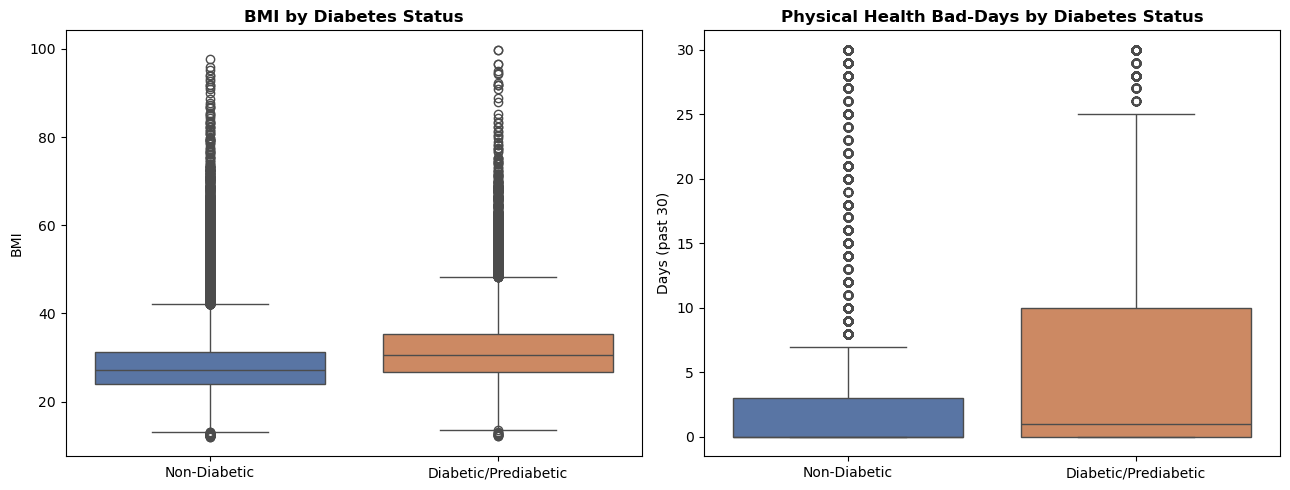

In [89]:
# ================================================================
# FIGURE 11: Boxplots comparing BMI and physical health by status
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x='diabetes_lbl', y='_BMI5', hue='diabetes_lbl',
            palette=['#4C72B0', '#DD8452'], legend=False, ax=axes[0])
axes[0].set_title('BMI by Diabetes Status', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('BMI')

sns.boxplot(data=df, x='diabetes_lbl', y='PHYSHLTH', hue='diabetes_lbl',
            palette=['#4C72B0', '#DD8452'], legend=False, ax=axes[1])
axes[1].set_title('Physical Health Bad-Days by Diabetes Status', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Days (past 30)')

plt.tight_layout()

In [90]:
df.to_csv(
    r"C:\Users\vithy\OneDrive\Documents\UCBerkley_Applied_AI_ML_2026\Capstone Project\data\LLCP2024\brfss_binary_clean.csv",
    index=False
)